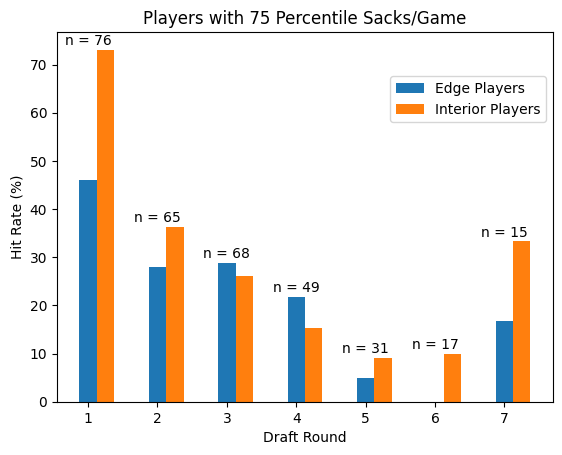

Edge
   round  total_edge  hit_edge  hit_rate_edge
0      1          50        23      46.000000
1      2          43        12      27.906977
2      3          45        13      28.888889
3      4          23         5      21.739130
4      5          20         1       5.000000
5      6           7         0       0.000000
6      7          12         2      16.666667
Interior
   round  total_interior  hit_interior  hit_rate_interior
0      1              26            19          73.076923
1      2              22             8          36.363636
2      3              23             6          26.086957
3      4              26             4          15.384615
4      5              11             1           9.090909
5      6              10             1          10.000000
6      7               3             1          33.333333


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DL_summary = pd.read_csv('dl_analysis_data.csv')

edge_rushers = DL_summary[DL_summary['position_group'] == 'Edge']
interior_dl = DL_summary[DL_summary['position_group'] == 'Interior']


drafted_edge = edge_rushers[edge_rushers['draft_round'].notna()].copy()
drafted_interior = interior_dl[interior_dl['draft_round'].notna()].copy()

edge_threshold_75 = edge_rushers['sacks_per_game'].quantile(.75)
interior_threshold_75 = interior_dl['sacks_per_game'].quantile(.75)

hit_75_edge = []
hit_75_interior = []

for dround in range (1,8):
    current_edge = drafted_edge['draft_round'] == dround
    current_interior = drafted_interior['draft_round'] == dround
    
    round_edge = drafted_edge[current_edge]
    round_interior = drafted_interior[current_interior]
    
    hit_75_edge_count = len(round_edge[round_edge['sacks_per_game'] >= edge_threshold_75])
    hit_75_edge_rate = (round_edge['sacks_per_game'] >= edge_threshold_75).mean() * 100
    
    hit_75_interior_count = len(round_interior[round_interior['sacks_per_game'] >= interior_threshold_75])
    hit_75_interior_rate = (round_interior['sacks_per_game'] >= interior_threshold_75).mean() * 100

    hit_75_edge.append({
        'round': int(dround),
        'total_edge': len(round_edge),
        'hit_edge': hit_75_edge_count,
        'hit_rate_edge': hit_75_edge_rate
    })
    hit_75_interior.append({
        'round': int(dround),
        'total_interior': len(round_interior),
        'hit_interior': hit_75_interior_count,
        'hit_rate_interior': hit_75_interior_rate
    })
    
df_edge_comp = pd.DataFrame(hit_75_edge)
df_interior_comp = pd.DataFrame(hit_75_interior)

rounds = list(df_edge_comp['round'])
width = .25
x = np.arange(len(rounds)) + 1

plt.bar(x, df_edge_comp['hit_rate_edge'], width, label='Edge Players')
plt.bar(x + width, df_interior_comp['hit_rate_interior'], width, label='Interior Players')

plt.xticks(x, rounds)
plt.xlabel('Draft Round')
plt.ylabel('Hit Rate (%)')
plt.title('Players with 75 Percentile Sacks/Game')
plt.legend(bbox_to_anchor=(1, .9), loc='upper right')

for r in range(1, 8):
    x_pos = r
    y_pos = max(df_edge_comp[df_edge_comp['round'] == r]['hit_rate_edge'].iloc[0], df_interior_comp[df_interior_comp['round'] == r]['hit_rate_interior'].iloc[0]) + 1
    count = df_edge_comp[df_edge_comp['round'] == r]['total_edge'].iloc[0] + df_interior_comp[df_interior_comp['round'] == r]['total_interior'].iloc[0]
    plt.text(x_pos, y_pos, f"n = {count}", ha='center')

plt.show()

print("Edge")
print(df_edge_comp.to_string())


print("Interior")
print(df_interior_comp.to_string())
